In [5]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as cas

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # needed in some Jupyter setups
from IPython.display import display, clear_output
import time
import numpy as np

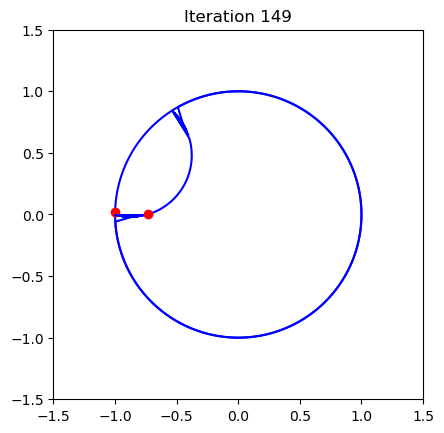

In [ ]:
def cas_Area_fun(len):
    
    x = cas.MX.sym('x',len,1)
    y = cas.MX.sym('y',len,1)
    
    area = cas.MX.zeros(1)

    for i in range(len-1):
        area = area + (y[i]+y[i+1])*((x[i]-x[i+1]))

    fun_area = cas.Function('fun_area',[x,y],[0.5 * cas.fabs(area)])

    return fun_area


def sorting_coordinates(x,y):
    
    angles = np.arctan2(y, x)
    sort_idx = np.argsort(angles)

    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]

    return x_sorted,y_sorted


coords = np.load('Coordinates_before.npy')
x_old = coords[0]
y_old = coords[1]

# x_old,y_old = sorting_coordinates(x_old,y_old)

coords = np.load('Coordinates_after.npy')
x_new = coords[0]
y_new = coords[1]

x_new = x_new.flatten()
y_new = y_new.flatten()

# x_new,y_new = sorting_coordinates(x_new,y_new)


N_points = 150

#  Main Circle in (x,y)
x_main_c = 0
y_main_c = 0

r_main   = 1
theta_main = np.linspace(0, 2*np.pi, N_points)

x_main = x_main_c +  r_main * np.cos(theta_main)
y_main = y_main_c +  r_main * np.sin(theta_main)

x_old,y_old = sorting_coordinates(x_main,y_main)

fig, ax = plt.subplots()

for i in range(N_points):
    ax.clear()

    ax.plot(x_old[:i+1], y_old[:i+1], 'b-')   # accumulated path so far
    ax.plot(x_old[i], y_old[i], 'ro')          # current point highlighted

    ax.plot(x_new[:i+1], y_new[:i+1], 'b-')   # accumulated path so far
    ax.plot(x_new[i], y_new[i], 'ro')          # current point highlighted
    
    ax.set_xlim(-1.5, 1.5)   # fix axes so plot doesn't jump around
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f"Iteration {i}")
    ax.set_aspect('equal')
    
    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

plt.close()

In [3]:
size_problem = np.size(x_old)

area_fun = cas_Area_fun(size_problem)

# area_main = area_fun(cas.DM(x_main.tolist()), cas.DM(y_main.tolist()))
area_main = area_fun(x_old,y_old)

opti = cas.Opti()

x_opti = opti.variable(size_problem)
y_opti = opti.variable(size_problem)

x_ref_opt = opti.parameter(size_problem)
y_ref_opt = opti.parameter(size_problem)

area = opti.parameter(1)

# J_cost = cas.norm_2(x_opti-x_ref_opt)**2 + cas.norm_2(y_opti-y_ref_opt)**2
J_cost = cas.norm_2(x_opti-x_old)**2 + cas.norm_2(y_opti-y_old)**2

opti.minimize(J_cost)

current_area = area_fun(x_opti,y_opti) 

# opti.subject_to(current_area==area)

opti.set_value(area,area_main)
opti.set_value(x_ref_opt, x_new)
opti.set_value(y_ref_opt, y_new)


# opti.set_initial(x_opti,x_old)
# opti.set_initial(y_opti,x_old)


opti.solver('ipopt')
sol = opti.solve()


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    22650

Total number of variables............................:      300
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

CasADi - 2026-05-14 20:23:27 WARNING("solver:nlp_grad_f failed: NaN detected for output grad_f_x, at (row 150, col 0).") [.../casadi/core/oracle_function.cpp:408]


RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Invalid_Number_Detected'

In [ ]:
x = sol.value(x_opti)
y = sol.value(y_opti)


plt.plot(x,y,color='red',linestyle='dotted')
# plt.plot(x_old,y_old,color='black')

plt.show()

# plt.plot(x_val,y_val,'-o')
# plt.show()